<a href="https://colab.research.google.com/github/Ash-IIT/Urbanmonitor/blob/main/DEMO_TAFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install -q xarray netCDF4 h5netcdf scipy matplotlib

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt

In [ ]:
!wget -q -O CESM2_sst_data.nc https://github.com/ProjectPythia/pythia-datasets/raw/main/data/CESM2_sst_data.nc
!wget -q -O CESM2_grid_variables.nc https://github.com/ProjectPythia/pythia-datasets/raw/main/data/CESM2_grid_variables.nc

In [ ]:
data = xr.open_dataset("CESM2_sst_data.nc")
grid = xr.open_dataset("CESM2_grid_variables.nc")

/usr/local/lib/python3.12/dist-packages/xarray/conventions.py:204: SerializationWarning: variable 'tos' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


In [ ]:
%pip install -q nc-time-axis

In [ ]:
areacello = grid["areacello"]
ds = xr.merge([data, areacello])
ds

<xarray.Dataset> Size: 47MB
Dimensions:    (time: 180, d2: 2, lat: 180, lon: 360)
Coordinates:
  * time       (time) object 1kB 2000-01-15 12:00:00 ... 2014-12-15 12:00:00
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: d2
Data variables:
    time_bnds  (time, d2) object 3kB ...
    lat_bnds   (lat, d2) float64 3kB ...
    lon_bnds   (lon, d2) float64 6kB ...
    tos        (time, lat, lon) float32 47MB ...
    areacello  (lat, lon) float64 518kB ...
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   674885.0
    branch_time_in_parent:  219000.0
    case_id:                972
    ...                     ...
    sub_experiment_id:      none
    table_id:               Omon
    tracking_id:            hdl:21.14100/2975ffd3-1d7b-47e3-961a-33f212ea4eb2
    variable_id:            tos
    variant_info:           CMIP6 20th century experiments (1850-2014) with C...
    variant_label:          r11i1p1f1

In [ ]:
tos_nino34 = ds.where(
    (ds.lat > -5) & (ds.lat < 5) & (ds.lon > 190) & (ds.lon < 240),
    drop=True
)
tos_nino34

<xarray.Dataset> Size: 2MB
Dimensions:    (time: 180, d2: 2, lat: 10, lon: 50)
Coordinates:
  * time       (time) object 1kB 2000-01-15 12:00:00 ... 2014-12-15 12:00:00
  * lat        (lat) float64 80B -4.5 -3.5 -2.5 -1.5 -0.5 0.5 1.5 2.5 3.5 4.5
  * lon        (lon) float64 400B 190.5 191.5 192.5 193.5 ... 237.5 238.5 239.5
Dimensions without coordinates: d2
Data variables:
    time_bnds  (time, d2, lat, lon) object 1MB 2000-01-01 00:00:00 ... 2015-0...
    lat_bnds   (lat, d2, lon) float64 8kB -5.0 -5.0 -5.0 -5.0 ... 5.0 5.0 5.0
    lon_bnds   (lon, d2, lat) float64 8kB 190.0 190.0 190.0 ... 240.0 240.0
    tos        (time, lat, lon) float32 360kB 28.26 28.16 28.06 ... 28.57 28.63
    areacello  (lat, lon) float64 4kB 1.233e+10 1.233e+10 ... 1.233e+10
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   674885.0
    branch_time_in_parent:  219000.0
    case_id:                972
    ...                     ...
    sub_experiment_id:      none
    table_id:               Omon
    tracking_id:            hdl:21.14100/2975ffd3-1d7b-47e3-961a-33f212ea4eb2
    variable_id:            tos
    variant_info:           CMIP6 20th century experiments (1850-2014) with C...
    variant_label:          r11i1p1f1

In [ ]:
gb = tos_nino34.tos.groupby("time.month")

In [ ]:
tos_nino34_anom = gb - gb.mean(dim="time")

In [ ]:
index_nino34 = tos_nino34_anom.weighted(tos_nino34.areacello).mean(dim=["lat", "lon"])

In [ ]:
index_nino34_rolling_mean = index_nino34.rolling(time=5, center=True).mean()

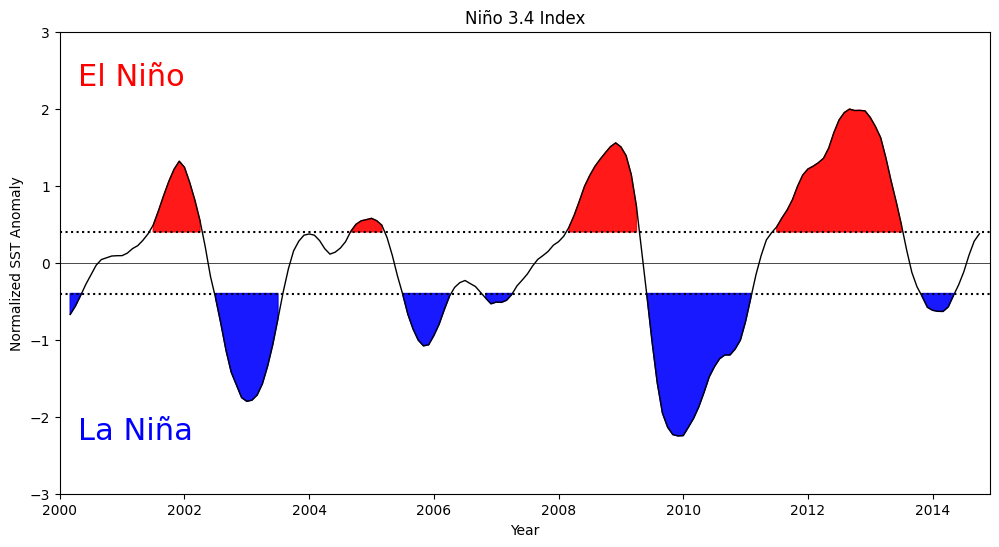

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Normalize the smoothed index
normalized_index = index_nino34_rolling_mean / index_nino34_rolling_mean.std()

times = normalized_index.time.values
vals = normalized_index.values

years = np.array([t.year + (t.month - 1)/12 for t in times])

fig, ax = plt.subplots(figsize=(12,6))

# Plot the time series
ax.plot(years, vals, color='black', linewidth=1)

# Fill El Niño
ax.fill_between(
    years,
    np.where(vals >= 0.4, vals, np.nan),
    0.4,
    color='red',
    alpha=0.9
)

# Fill La Niña
ax.fill_between(
    years,
    np.where(vals <= -0.4, vals, np.nan),
    -0.4,
    color='blue',
    alpha=0.9
)

# Reference lines
ax.axhline(0, color='black', lw=0.5)
ax.axhline(0.4, color='black', linestyle='dotted')
ax.axhline(-0.4, color='black', linestyle='dotted')

# Set limits BEFORE adding text
ax.set_ylim(-3,3)
ax.set_xlim(years.min(), years.max())

# Add El Niño / La Niña labels
ax.text(years.min()+0.3, 2.3, "El Niño", color="red", fontsize=22)
ax.text(years.min()+0.3, -2.3, "La Niña", color="blue", fontsize=22)

# Title and labels
ax.set_title("Niño 3.4 Index")
ax.set_xlabel("Year")
ax.set_ylabel("Normalized SST Anomaly")

plt.show()